In [50]:
import pandas as pd
from collections import defaultdict
import re
import networkx as nx
import matplotlib.pyplot as plt
import random

In [8]:
#loading the dataset
#DATASET ORIGIN: https://www.kaggle.com/datasets/amaleshvemula7/name-and-country-of-origin-dataset
df = pd.read_csv('data.csv')
df.head(20)

,Name,Country_code,Country
0,Amy Johnson,ar_AE,AE
1,Thomas Wright,ar_AE,AE
2,Mr. Marco Flores DDS,ar_AE,AE
3,Marcus Robbins,ar_AE,AE
4,Susan Montgomery,ar_AE,AE
5,David Byrd,ar_AE,AE
6,Maureen Watts,ar_AE,AE
7,Kenneth Morales,ar_AE,AE
8,Erica Davis,ar_AE,AE
9,Tom Wilson,ar_AE,AE


In [28]:
#Extracting names only
names = df["Name"].dropna()
#names = names.str.extract(r"([A-Za-z' -]+)")

names = names[names.str.match(r"^[A-Za-z' -]+$")]
names = names.str.strip()
names = names[names.str.len() > 2]

names.head(5)

,Name
0,Amy Johnson
1,Thomas Wright
3,Marcus Robbins
4,Susan Montgomery
5,David Byrd


In [29]:
def BuildGraph(names):
  graph = defaultdict(lambda: defaultdict(int))
  """
  so basically, inshort it does this thing in 1 line (pro tricks used cuz why not):
  graph = {}

  if curr_char not in graph:
      graph[curr_char] = {}

  if next_char not in graph[curr_char]:
      graph[curr_char][next_char] = 0


  """

  for name in names:
    if not isinstance(name, str):
      continue
   # print(name)
    name = "^" + name.lower() + "$" # ^ indicates start of the name and $ end
    for i in range(len(name)-1):
      curr = name[i]
      next = name[i + 1]
      graph[curr][next] += 1

  return graph


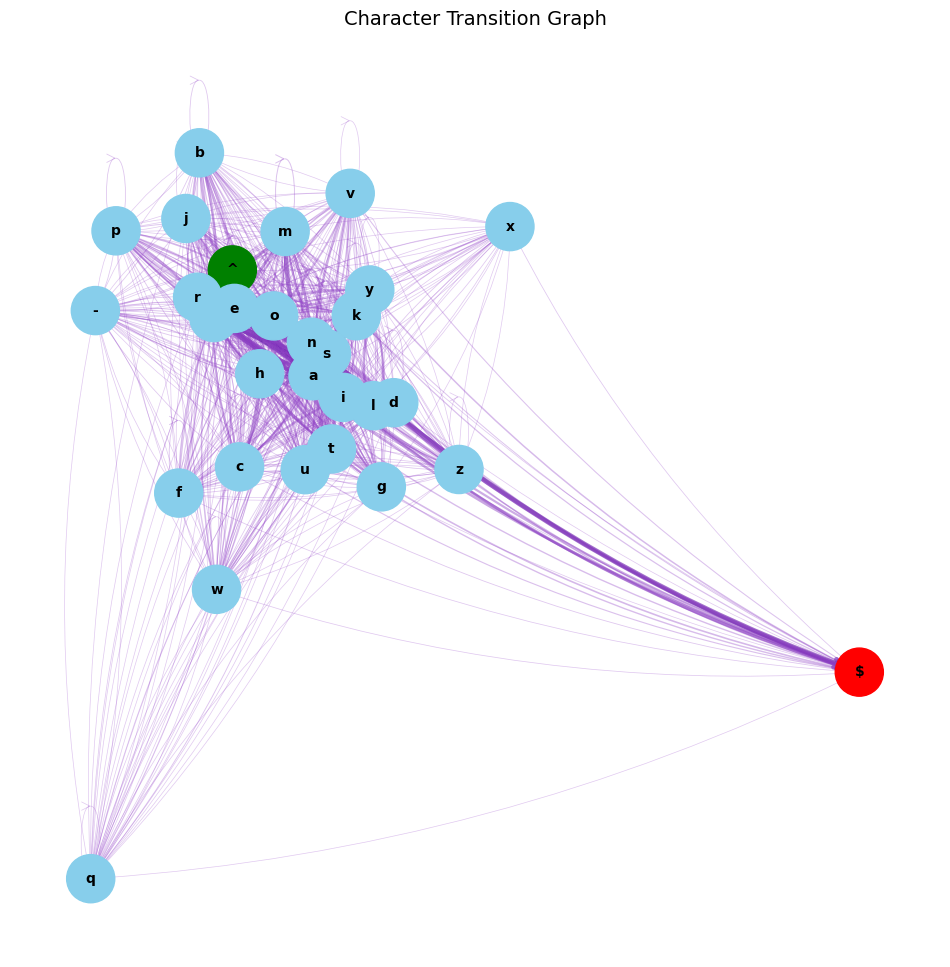

In [48]:
#building name graph and visualizing it
graph = BuildGraph(names)

#2d visualize
#This function is generated by chatgpt

def visualize_graph(graph):
    G = nx.DiGraph()

    for src in graph:
        for dst, weight in graph[src].items():
            G.add_edge(src, dst, weight=weight)

    pos = nx.spring_layout(G, k=1.5, iterations=100)

    plt.figure(figsize=(12, 12))

    # Node colors
    node_colors = []
    for node in G.nodes():
        if node == "^":
            node_colors.append("green")
        elif node == "$":
            node_colors.append("red")
        else:
            node_colors.append("skyblue")

    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=1200
    )

    # Edge weights
    edges = list(G.edges(data=True))
    weights = [d['weight'] for (_, _, d) in edges]

    max_w = max(weights) if weights else 1
    min_w = min(weights) if weights else 0

    edge_colors = []
    widths = []

    for w in weights:
        # Normalize (0 → 1)
        norm = (w - min_w) / (max_w - min_w + 1e-6)

        # Color: purple → violet
        # purple (low):  (0.6, 0.3, 0.8)
        # violet (high): (0.3, 0.0, 0.6)
        r = 0.6 - 0.3 * norm
        g = 0.3 - 0.3 * norm
        b = 0.8 - 0.2 * norm

        # Alpha: lighter → darker
        alpha = 0.3 + 0.7 * norm

        edge_colors.append((r, g, b, alpha))

        # Thickness
        widths.append(0.5 + norm * 6)

    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v) for u, v, _ in edges],
        width=widths,
        edge_color=edge_colors,
        arrows=True,
        arrowstyle='->',
        arrowsize=15,
        connectionstyle='arc3,rad=0.1'
    )

    nx.draw_networkx_labels(
        G, pos,
        font_size=10,
        font_weight="bold"
    )

    plt.title("Character Transition Graph", fontsize=14)
    plt.axis("off")
    plt.show()

visualize_graph(graph)

In [51]:
#random name generator
def weighted_random(choices):
    total = sum(choices.values())
    r = random.uniform(0, total)

    upto = 0
    for char, weight in choices.items():
        upto += weight
        if upto >= r:
            return char

def generate_name(graph, start="^", max_length=20):
    current = start
    result = ""

    while True:
        if current not in graph:
            break

        next = weighted_random(graph[current])

        if next == "$":
            break

        result += next
        current = next

        if len(result) >= max_length:
            break

    return result

In [57]:
#test
print(generate_name(graph))

putar bostz
